<!-- @q -->
## Problem 1 

Using the data in the `2019_Yellow_Taxi_Trip_Data.csv` file, calculate summary statistics for the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` columns:

In [81]:
import pandas as pd
rides_df = pd.read_csv("data/2019_Yellow_Taxi_Trip_Data.csv")
rides_df[['fare_amount', 'tip_amount', 'tolls_amount', 'total_amount']].describe()


,fare_amount,tip_amount,tolls_amount,total_amount
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,15.106313,2.634494,0.623447,22.564659
std,13.954762,3.409800,6.437507,19.209255
min,-52.000000,0.000000,-6.120000,-65.920000
25%,7.000000,0.000000,0.000000,12.375000
50%,10.000000,2.000000,0.000000,16.300000
75%,16.000000,3.250000,0.000000,22.880000
max,176.000000,43.000000,612.000000,671.800000


<!-- @q -->
## Problem 2

Isolate the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` for the longest trip by distance (`trip_distance`):

In [82]:

import pandas as pd
taxi_df = pd.read_csv("data/2019_Yellow_Taxi_Trip_Data.csv")
max_distance_idx = taxi_df['trip_distance'].idxmax()
longest_journey = taxi_df.loc[
    max_distance_idx,
    ['fare_amount', 'tip_amount', 'tolls_amount', 'total_amount', 'trip_distance']
]

print(longest_journey)


fare_amount       176.0
tip_amount        18.29
tolls_amount       6.12
total_amount     201.21
trip_distance     38.11
Name: 8338, dtype: object


<!-- @q -->
## Problem 3 

Read in the meteorite data from the `Meteorite_Landings.csv` file, rename the `mass (g)` column to `mass`, and drop all the latitude and longitude columns. Sort the result by mass in descending order.

In [83]:
import pandas as pd

meteorites_df = pd.read_csv("data/Meteorite_Landings.csv")
sorted_meteorites = (
    meteorites_df
    .rename(columns={'mass (g)': 'mass'})
    .drop(columns=['reclat', 'reclong', 'GeoLocation'], errors='ignore')
    .sort_values('mass', ascending=False)
)
sorted_meteorites.head()


,name,id,nametype,recclass,mass,fall,year
16392,Hoba,11890,Valid,"Iron, IVB",60000000.0,Found,01/01/1920 12:00:00 AM
5373,Cape York,5262,Valid,"Iron, IIIAB",58200000.0,Found,01/01/1818 12:00:00 AM
5365,Campo del Cielo,5247,Valid,"Iron, IAB-MG",50000000.0,Found,12/22/1575 12:00:00 AM
5370,Canyon Diablo,5257,Valid,"Iron, IAB-MG",30000000.0,Found,01/01/1891 12:00:00 AM
3455,Armanty,2335,Valid,"Iron, IIIE",28000000.0,Found,01/01/1898 12:00:00 AM


<!-- @q -->
## Problem 4

Using the meteorite data from the `Meteorite_Landings.csv` file, update the `year` column to only contain the year, convert it to a numeric data type, and create a new column indicating whether the meteorite was observed falling before 1970. Set the index to the `id` column and extract all the rows with IDs between 10,036 and 10,040 (inclusive) with `loc[]`.

**Hint 1**: Use `year.str.slice()` to grab a substring.

**Hint 2**: Make sure to sort the index before using `loc[]` to select the range.

In [84]:
import pandas as pd
meteorites_df['year'] = meteorites_df['year'].str.slice(6, 10)
meteorites_df['year'] = pd.to_numeric(meteorites_df['year'], errors='coerce')


meteorites_df['pre_1970'] = meteorites_df['year'] < 1970


meteorite_indexed = meteorites_df.set_index('id').sort_index()


subset = meteorite_indexed.loc[10036:10040]
subset




,name,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation,pre_1970
id,,,,,,,,,,
10036,Enigma,Valid,H4,94.0,Found,1967.0,31.33333,-82.31667,"(31.33333, -82.31667)",True
10037,Enon,Valid,"Iron, ungrouped",763.0,Found,1883.0,39.86667,-83.95000,"(39.86667, -83.95)",True
10038,Enshi,Valid,H5,8000.0,Fell,1974.0,30.30000,109.50000,"(30.3, 109.5)",False
10039,Ensisheim,Valid,LL6,127000.0,Fell,1491.0,47.86667,7.35000,"(47.86667, 7.35)",True


**BONUS**: There's a data entry error in the `year` column. Can you find it?

In [85]:
future_meteorite = meteorites_df[meteorites_df['year'] > 2025]
future_meteorite




,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation,pre_1970
30682,Northwest Africa 7701,57150,Valid,CK6,55.0,Found,2101.0,0.0,0.0,"(0.0, 0.0)",False


There's a meteorite that was reportedly found in the future:

In [86]:
future_meteorite = meteorites_df[meteorites_df['year'] > 2025]
print("Meteorite found in the future:\n", future_meteorite)


meteorites_df.loc[future_meteorite.index, 'year'] = 2010


print("\nCorrected record:\n", meteorites_df.loc[future_meteorite.index])


Meteorite found in the future:
                         name     id nametype recclass  mass (g)   fall  \
30682  Northwest Africa 7701  57150    Valid      CK6      55.0  Found   

         year  reclat  reclong GeoLocation  pre_1970  
30682  2101.0     0.0      0.0  (0.0, 0.0)     False  

Corrected record:
                         name     id nametype recclass  mass (g)   fall  \
30682  Northwest Africa 7701  57150    Valid      CK6      55.0  Found   

         year  reclat  reclong GeoLocation  pre_1970  
30682  2010.0     0.0      0.0  (0.0, 0.0)     False  


_This meteorite actually was found in 2010 (more information [here](https://www.lpi.usra.edu/meteor/metbull.php?code=57150))._

<!-- @q -->
## Problem 5

Using the taxi trip data in the `2019_Yellow_Taxi_Trip_Data.csv` file, resample the data to an hourly frequency based on the dropoff time. Calculate the total `trip_distance`, `fare_amount`, `tolls_amount`, and `tip_amount`, then find the 5 hours with the most tips.

In [87]:
taxi_df['dropoff_time'] = pd.to_datetime(taxi_df['tpep_dropoff_datetime'])

hourly_stats = (
    taxi_df
    .set_index('dropoff_time')
    .resample('1H')
    .agg({
        'trip_distance': 'sum',
        'fare_amount': 'sum',
        'tolls_amount': 'sum',
        'tip_amount': 'sum'
    })
)

highest_tip_hours = hourly_stats.sort_values('tip_amount', ascending=False).iloc[:5]
highest_tip_hours


/tmp/ipykernel_21710/2915997702.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample('1H')


,trip_distance,fare_amount,tolls_amount,tip_amount
dropoff_time,,,,
2019-10-23 16:00:00,10676.95,67797.76,699.04,12228.64
2019-10-23 17:00:00,16052.83,70131.91,4044.04,12044.03
2019-10-23 18:00:00,3104.56,11565.56,1454.67,1907.64
2019-10-23 15:00:00,14.34,213.50,0.00,51.75
2019-10-23 19:00:00,98.59,268.00,24.48,25.74


<!-- @q -->
## Problem 6

Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create box plots for traveler throughput for each year in the data. Hint: Pass `kind='box'` into the `plot()` method to generate box plots.

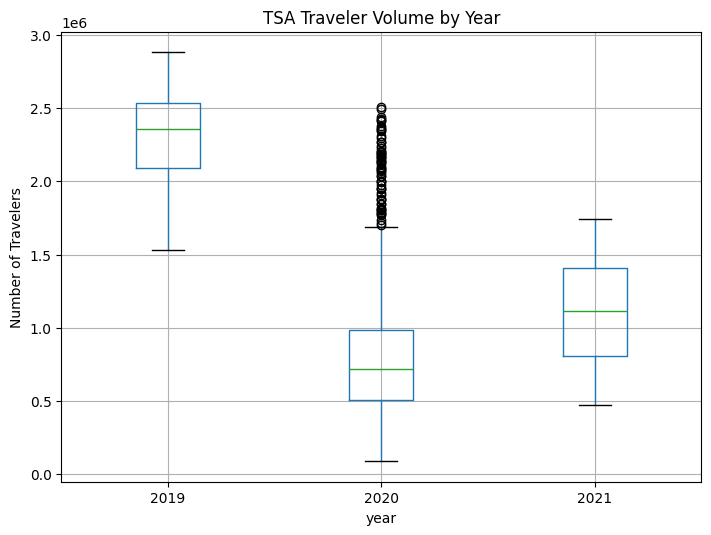

In [88]:
import matplotlib.pyplot as plt
import pandas as pd
travel_df = pd.read_csv("data/tsa_melted_holiday_travel.csv")
ax = travel_df.boxplot(column="travelers", by="year", figsize=(8, 6))
plt.title("TSA Traveler Volume by Year")
plt.suptitle("")  # remove automatic suptitle
plt.ylabel("Number of Travelers")
plt.show()


<!-- @q -->
## Problem 7
Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create a heatmap that shows the 2019 TSA median traveler throughput by day of week and month.

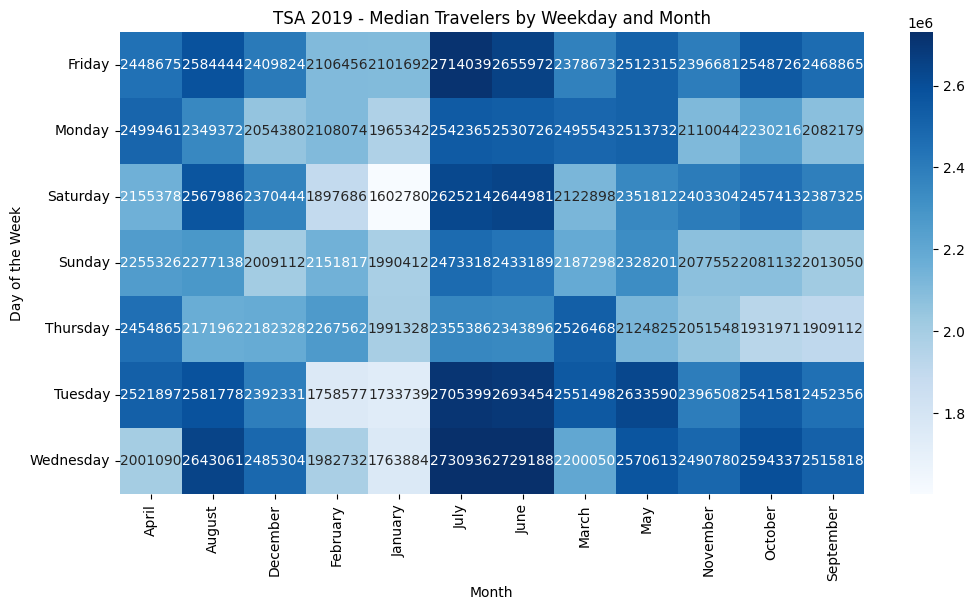

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

tsa_df_2019 = travel_df[travel_df['year'] == 2019].copy()


tsa_df_2019['flight_date'] = pd.to_datetime(tsa_df_2019['date'])
tsa_df_2019['weekday'] = tsa_df_2019['flight_date'].dt.day_name()
tsa_df_2019['month_name'] = tsa_df_2019['flight_date'].dt.month_name()


pivot_table = (
    tsa_df_2019.groupby(['weekday', 'month_name'])['travelers']
    .median()
    .unstack()
)


plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap="Blues", annot=True, fmt=".0f")
plt.title("TSA 2019 - Median Travelers by Weekday and Month")
plt.ylabel("Day of the Week")
plt.xlabel("Month")
plt.show()

